# Identifiability Analysis — AV Duration Estimation

This notebook summarises the model-identifiability analyses done in response to the eLife desk rejection. The editors requested simulations showing under which conditions the competing models can be disentangled.

**Sections**
1. Participant sensory noise estimates (σ_a, σ_v) from model fits  
2. Model comparison — AIC / BIC across participants  
3. Why the empirical regime limits identifiability  
4. Divergence diagnostic — cheap identifiability landscape  
5. Model-recovery sweep — diagonal recovery vs (σ, conflict range)  
6. Confusion matrices per regime  
7. PSE-curve separation by regime  

In [1]:
import json, os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import glob

plt.rcParams.update({'figure.dpi': 150, 'font.size': 11,
                     'axes.spines.top': False, 'axes.spines.right': False})

MODEL_ABBR = {
    'lognorm':                    'CI',
    'fusionOnlyLogNorm':          'Fusion',
    'switchingFree':              'Switching',
    'probabilityMatchingLogNorm': 'Prob. Match.',
    'selection':                  'Selection',
}
MODEL_COLORS = {
    'lognorm':                    '#1f77b4',
    'fusionOnlyLogNorm':          '#ff7f0e',
    'switchingFree':              '#2ca02c',
    'probabilityMatchingLogNorm': '#d62728',
    'selection':                  '#9467bd',
}

FITS_DIR = 'model_fits'
MODELS   = ['lognorm', 'fusionOnlyLogNorm', 'switchingFree',
             'probabilityMatchingLogNorm', 'selection']

# Full-vector param layouts (sharedLambda=True)
# lognorm:           [λ, σa1, σv, p_c, σa2]
# fusionOnlyLogNorm: [λ, σa1, σv, σa2]
# switchingFree:     [λ, σa1, σv, p_sw1, σa2, p_sw2]
# probabilityMatchingLogNorm / selection: same as lognorm
PARAM_IDX = {
    'lambda': {m: 0 for m in MODELS},
    'sigma_a1': {m: 1 for m in MODELS},          # low-noise condition
    'sigma_v':  {m: 2 for m in MODELS},
    'sigma_a2': {'lognorm': 4, 'fusionOnlyLogNorm': 3,
                 'switchingFree': 4, 'probabilityMatchingLogNorm': 4,
                 'selection': 4},
    'p_c':      {'lognorm': 3, 'probabilityMatchingLogNorm': 3, 'selection': 3},
    'p_sw1':    {'switchingFree': 3},
}

def load_fits():
    pids = sorted([d for d in os.listdir(FITS_DIR)
                   if os.path.isdir(os.path.join(FITS_DIR, d))
                   and d not in ['.DS_Store', 'all']])
    rows = []
    for pid in pids:
        for model in MODELS:
            suffix = f'{model}_LapseFix_sharedPrior'
            fp = os.path.join(FITS_DIR, pid, f'{pid}_{suffix}_fit.json')
            if not os.path.exists(fp):
                continue
            with open(fp) as f:
                r = json.load(f)
            p = r['fittedParams']
            row = dict(pid=pid, model=model,
                       AIC=r['AIC'], BIC=r['BIC'], LL=r['logLikelihood'],
                       nParams=len(p),
                       lam=p[0], sigma_a1=p[1], sigma_v=p[2],
                       sigma_a2=p[PARAM_IDX['sigma_a2'][model]] if model in PARAM_IDX['sigma_a2'] else np.nan,
                       sigma_a_mean=np.mean([p[1], p[PARAM_IDX['sigma_a2'][model]]]) if model in PARAM_IDX['sigma_a2'] else p[1],
                       p_c=p[3] if model in ['lognorm','probabilityMatchingLogNorm','selection'] else np.nan,
                       p_sw=p[3] if model == 'switchingFree' else np.nan)
            rows.append(row)
    return pd.DataFrame(rows)

df = load_fits()
print(f'Loaded {df["pid"].nunique()} participants × {df["model"].nunique()} models = {len(df)} fits')
df.head(6)

Loaded 11 participants × 5 models = 55 fits


,pid,model,AIC,BIC,LL,nParams,lam,sigma_a1,sigma_v,sigma_a2,sigma_a_mean,p_c,p_sw
0,P01,lognorm,2248.748703,2268.985563,-1119.374351,5,0.054969,0.241329,0.606782,0.632321,0.436825,1.000000,NaN
1,P01,fusionOnlyLogNorm,2246.437345,2262.626834,-1119.218672,4,0.054879,0.238490,0.593979,0.579842,0.409166,NaN,NaN
2,P01,switchingFree,2251.087865,2275.372098,-1119.543933,6,0.041798,0.248199,0.000113,0.577344,0.412772,NaN,0.092697
3,P01,probabilityMatchingLogNorm,2249.399181,2269.636042,-1119.699590,5,0.052201,0.241990,0.589356,0.616575,0.429283,0.000003,NaN
4,P01,selection,2255.129539,2275.366400,-1122.564769,5,0.011277,0.135116,0.318739,0.295883,0.215500,0.736245,NaN
5,P02,lognorm,2549.546215,2570.114626,-1269.773107,5,0.246876,0.217073,0.335323,0.582083,0.399578,0.608586,NaN


## 1. Sensory noise estimates per participant

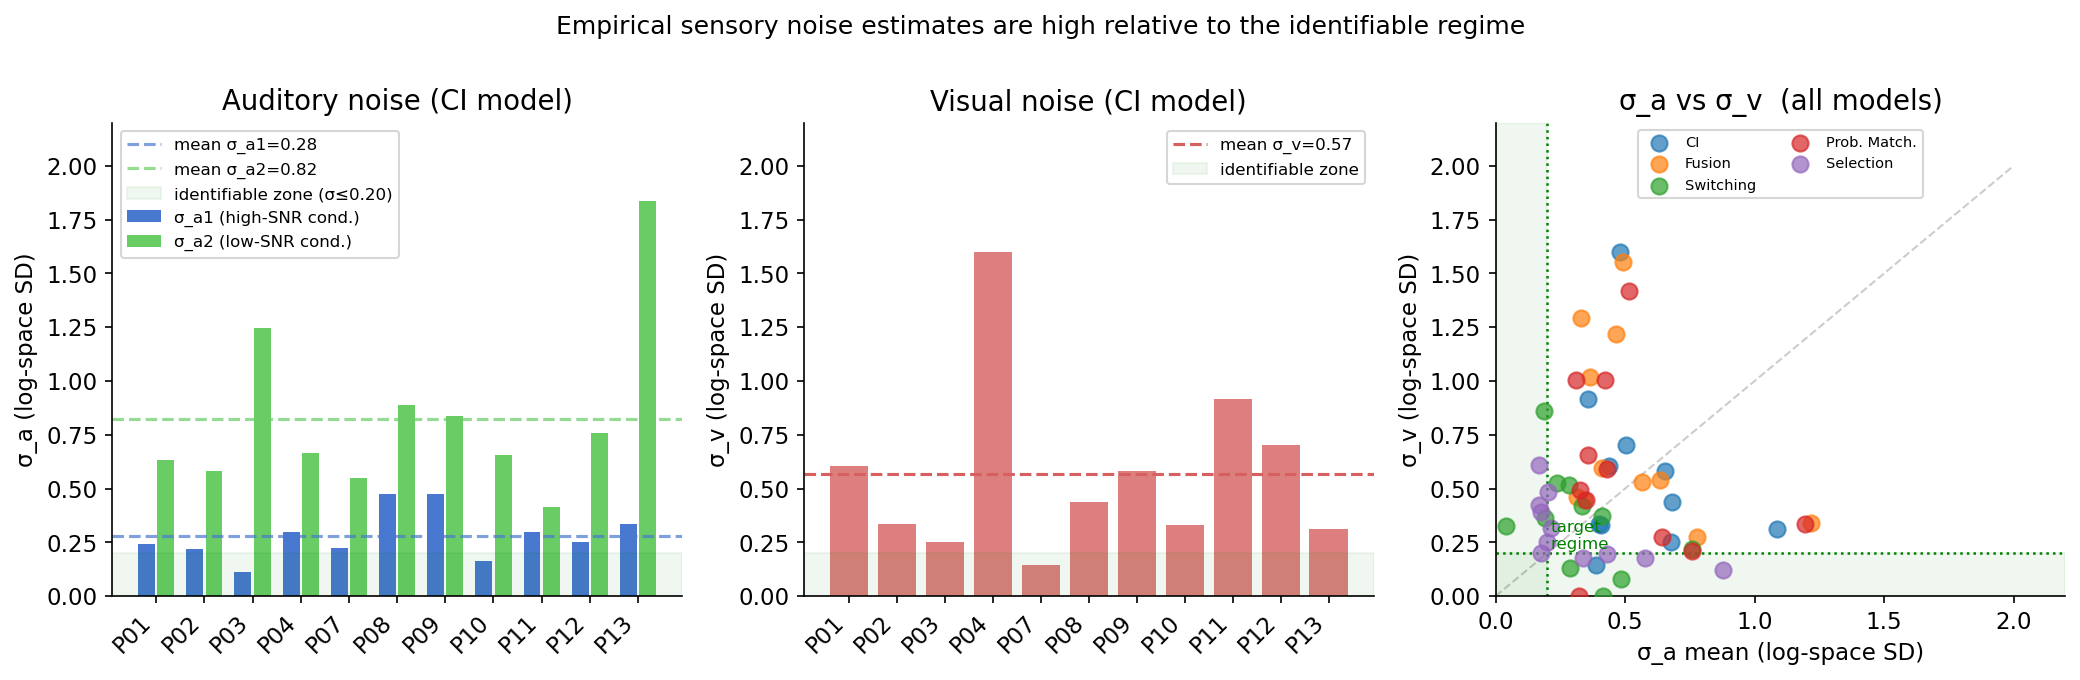

In [2]:
# Use lognorm (CI) as the reference model for displaying σ estimates
ci_df = df[df['model'] == 'lognorm'].copy()

fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))

# --- Panel A: σ_a (mean across both SNR conditions) per participant ---
ax = axes[0]
x = np.arange(len(ci_df))
ax.bar(x - 0.2, ci_df['sigma_a1'].values, 0.35, label='σ_a1 (high-SNR cond.)', color='#4878cf')
ax.bar(x + 0.2, ci_df['sigma_a2'].values, 0.35, label='σ_a2 (low-SNR cond.)',  color='#6acc65')
ax.axhline(ci_df['sigma_a1'].mean(), ls='--', color='#4878cf', alpha=0.7,
           label=f'mean σ_a1={ci_df["sigma_a1"].mean():.2f}')
ax.axhline(ci_df['sigma_a2'].mean(), ls='--', color='#6acc65', alpha=0.7,
           label=f'mean σ_a2={ci_df["sigma_a2"].mean():.2f}')
# shade the identifiable zone
ax.axhspan(0, 0.20, color='green', alpha=0.06, label='identifiable zone (σ≤0.20)')
ax.set_xticks(x); ax.set_xticklabels(ci_df['pid'].values, rotation=45, ha='right')
ax.set_ylabel('σ_a (log-space SD)')
ax.set_title('Auditory noise (CI model)')
ax.legend(fontsize=8, loc='upper left')
ax.set_ylim(0, 2.2)

# --- Panel B: σ_v per participant ---
ax = axes[1]
ax.bar(x, ci_df['sigma_v'].values, color='#d65f5f', alpha=0.8)
ax.axhline(ci_df['sigma_v'].mean(), ls='--', color='#d65f5f',
           label=f'mean σ_v={ci_df["sigma_v"].mean():.2f}')
ax.axhspan(0, 0.20, color='green', alpha=0.06, label='identifiable zone')
ax.set_xticks(x); ax.set_xticklabels(ci_df['pid'].values, rotation=45, ha='right')
ax.set_ylabel('σ_v (log-space SD)')
ax.set_title('Visual noise (CI model)')
ax.legend(fontsize=8)
ax.set_ylim(0, 2.2)

# --- Panel C: scatter σ_a_mean vs σ_v per participant (all models) ---
ax = axes[2]
for model in MODELS:
    sub = df[df['model'] == model]
    ax.scatter(sub['sigma_a_mean'], sub['sigma_v'],
               label=MODEL_ABBR[model], color=MODEL_COLORS[model],
               s=60, alpha=0.7, zorder=3)
# Shade identifiable region
ax.axvspan(0, 0.20, color='green', alpha=0.06)
ax.axhspan(0, 0.20, color='green', alpha=0.06)
ax.axvline(0.20, ls=':', color='green', lw=1.2)
ax.axhline(0.20, ls=':', color='green', lw=1.2)
ax.text(0.21, 0.22, 'target\nregime', color='green', fontsize=8)
ax.plot([0, 2], [0, 2], 'k--', alpha=0.2, lw=1)
ax.set_xlabel('σ_a mean (log-space SD)')
ax.set_ylabel('σ_v (log-space SD)')
ax.set_title('σ_a vs σ_v  (all models)')
ax.legend(fontsize=7, ncol=2)
ax.set_xlim(0, 2.2); ax.set_ylim(0, 2.2)

fig.suptitle('Empirical sensory noise estimates are high relative to the identifiable regime',
              fontsize=12, y=1.0)
plt.tight_layout()
plt.savefig('identifiability_figures/fig_noise_estimates.pdf', bbox_inches='tight')
plt.savefig('identifiability_figures/fig_noise_estimates.png', bbox_inches='tight', dpi=200)
plt.show()

## 2. Model comparison — AIC across participants

Best model per participant (AIC):
pid             model         AIC
P01 fusionOnlyLogNorm 2246.437345
P02         selection 2546.394308
P03         selection 1187.477990
P04     switchingFree 2401.432791
P07           lognorm 2167.374294
P08           lognorm 2438.929626
P09         selection 2491.127468
P10     switchingFree 2207.741391
P11     switchingFree 2319.577582
P12 fusionOnlyLogNorm 2498.542089
P13     switchingFree 2140.065402

Model wins:
model
switchingFree        4
selection            3
fusionOnlyLogNorm    2
lognorm              2
Name: count, dtype: int64


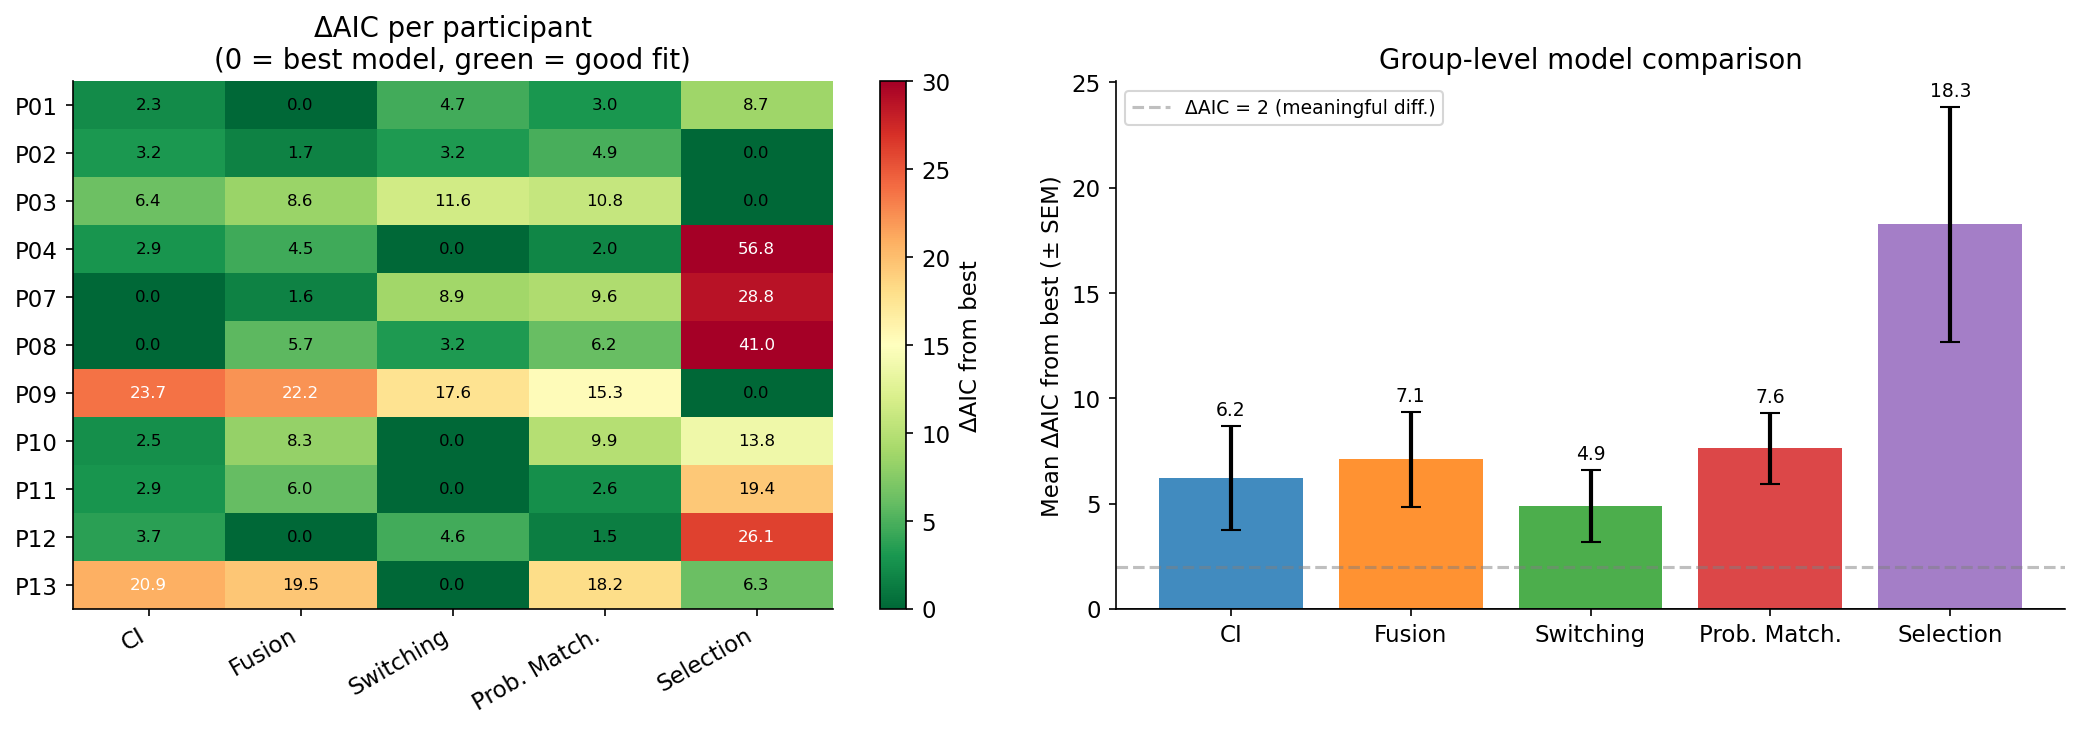

In [3]:
# Best model per participant (lowest AIC)
best = df.loc[df.groupby('pid')['AIC'].idxmin()][['pid', 'model', 'AIC']]
print('Best model per participant (AIC):')
print(best.to_string(index=False))
print()
print('Model wins:')
print(best['model'].value_counts())

# ΔAIC relative to best model per participant
df2 = df.copy()
df2['dAIC'] = df2.groupby('pid')['AIC'].transform(lambda x: x - x.min())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Left: ΔAIC per participant (heatmap) ---
ax = axes[0]
pivot = df2.pivot(index='pid', columns='model', values='dAIC')
pivot.columns = [MODEL_ABBR[m] for m in pivot.columns]
pivot = pivot[['CI', 'Fusion', 'Switching', 'Prob. Match.', 'Selection']]
im = ax.imshow(pivot.values, aspect='auto', cmap='RdYlGn_r', vmin=0, vmax=30)
ax.set_xticks(range(len(pivot.columns))); ax.set_xticklabels(pivot.columns, rotation=30, ha='right')
ax.set_yticks(range(len(pivot.index))); ax.set_yticklabels(pivot.index)
for i in range(pivot.shape[0]):
    for j in range(pivot.shape[1]):
        v = pivot.values[i, j]
        ax.text(j, i, f'{v:.1f}', ha='center', va='center', fontsize=8,
                color='white' if v > 20 else 'black')
plt.colorbar(im, ax=ax, label='ΔAIC from best')
ax.set_title('ΔAIC per participant\n(0 = best model, green = good fit)')

# --- Right: Mean ΔAIC ± SEM ---
ax = axes[1]
means = df2.groupby('model')['dAIC'].agg(['mean', 'sem']).loc[MODELS]
abbrs = [MODEL_ABBR[m] for m in MODELS]
colors = [MODEL_COLORS[m] for m in MODELS]
bars = ax.bar(abbrs, means['mean'], yerr=means['sem'], capsize=5,
               color=colors, alpha=0.85, error_kw={'lw': 2})
ax.set_ylabel('Mean ΔAIC from best (± SEM)')
ax.set_title('Group-level model comparison')
ax.axhline(2, ls='--', color='gray', alpha=0.5, label='ΔAIC = 2 (meaningful diff.)')
ax.axhline(0, ls='-', color='black', lw=0.8)
ax.legend(fontsize=9)
for bar, (_, row) in zip(bars, means.iterrows()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + row['sem'] + 0.3,
            f"{row['mean']:.1f}", ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('identifiability_figures/fig_model_comparison_AIC.pdf', bbox_inches='tight')
plt.savefig('identifiability_figures/fig_model_comparison_AIC.png', bbox_inches='tight', dpi=200)
plt.show()

## 3. p_c and p_switch estimates

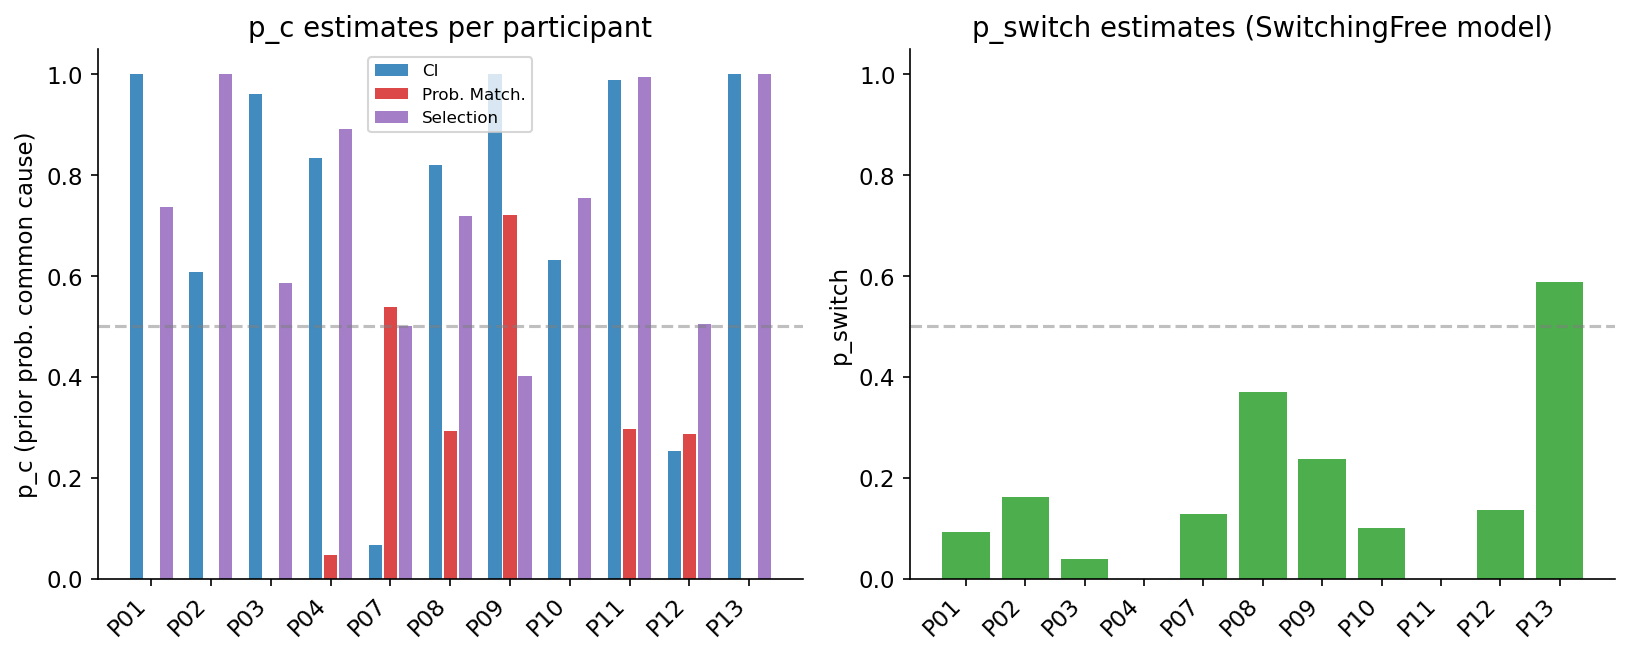

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

# p_c for CI-like models
ax = axes[0]
pids_sorted = sorted(df['pid'].unique())
x = np.arange(len(pids_sorted))
for i, model in enumerate(['lognorm', 'probabilityMatchingLogNorm', 'selection']):
    sub = df[df['model'] == model].set_index('pid').reindex(pids_sorted)
    offset = (i - 1) * 0.25
    ax.bar(x + offset, sub['p_c'].values, 0.22,
           label=MODEL_ABBR[model], color=MODEL_COLORS[model], alpha=0.85)
ax.set_xticks(x); ax.set_xticklabels(pids_sorted, rotation=45, ha='right')
ax.set_ylabel('p_c (prior prob. common cause)')
ax.set_ylim(0, 1.05)
ax.axhline(0.5, ls='--', color='gray', alpha=0.5)
ax.set_title('p_c estimates per participant')
ax.legend(fontsize=8)

# p_switch for switchingFree
ax = axes[1]
sw = df[df['model'] == 'switchingFree'].set_index('pid').reindex(pids_sorted)
ax.bar(x, sw['p_sw'].values, color=MODEL_COLORS['switchingFree'], alpha=0.85)
ax.set_xticks(x); ax.set_xticklabels(pids_sorted, rotation=45, ha='right')
ax.set_ylabel('p_switch')
ax.set_ylim(0, 1.05)
ax.axhline(0.5, ls='--', color='gray', alpha=0.5)
ax.set_title('p_switch estimates (SwitchingFree model)')

plt.tight_layout()
plt.savefig('identifiability_figures/fig_pc_estimates.pdf', bbox_inches='tight')
plt.savefig('identifiability_figures/fig_pc_estimates.png', bbox_inches='tight', dpi=200)
plt.show()

## 4. Divergence diagnostic — identifiability landscape

For each (σ, conflict_max) cell we compute the mean absolute difference in predicted p(test_longer) across all stimulus conditions and all model pairs. This requires no fitting and gives a smooth landscape.

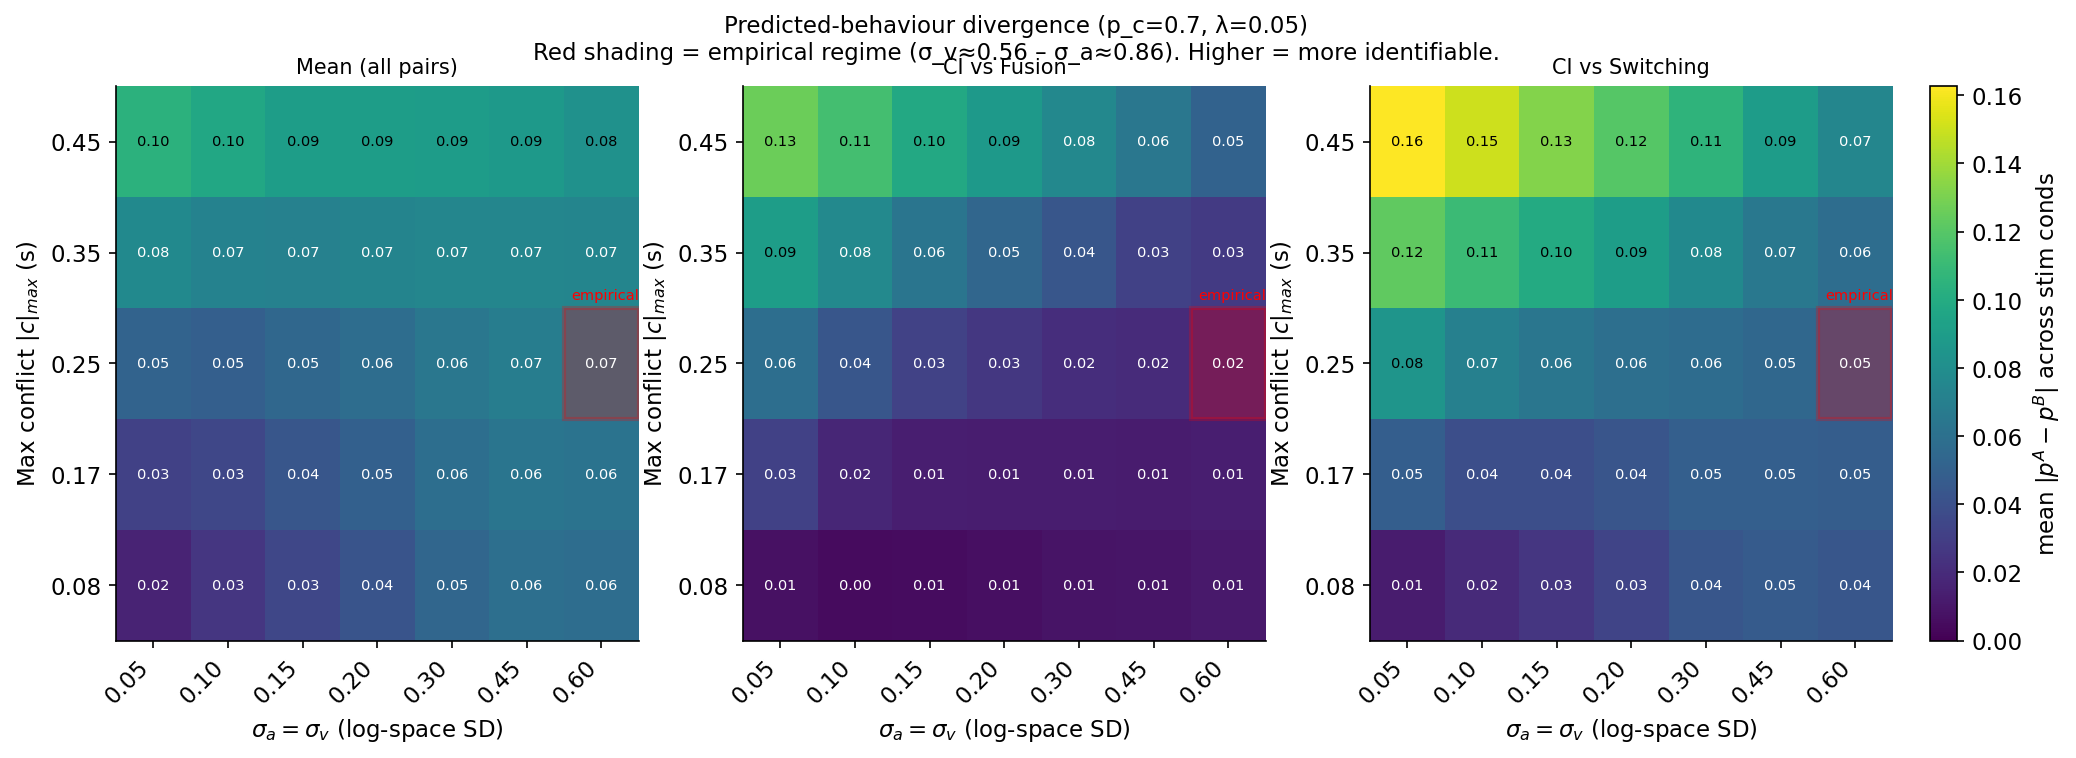

Empirical regime  (σ_v≈0.56, cmax=0.25): divergence = 0.067
Low-noise regime  (σ=0.10,   cmax=0.45): divergence = 0.098
Ratio: 1.5×


In [5]:
div_df = pd.read_csv('model_divergence_results/divergence_grid.csv')
sub = div_df[np.isclose(div_df['p_c'], 0.7)].copy()

piv_mean   = sub.pivot_table(index='conflict_max', columns='sigma_a',
                              values='mean_pairwise').sort_index(ascending=False)
piv_ci_fus = sub.pivot_table(index='conflict_max', columns='sigma_a',
                              values='lognorm__vs__fusionOnlyLogNorm').sort_index(ascending=False)
piv_ci_sw  = sub.pivot_table(index='conflict_max', columns='sigma_a',
                              values='lognorm__vs__switchingFree').sort_index(ascending=False)

# Empirical: σ_a≈0.86, σ_v≈0.56, conflict_max=0.25
# Shade column range between nearest grid points for σ_v and σ_a
def annotated_heatmap(ax, pivot, title, vmax, emp_sigma_v=0.56, emp_sigma_a=0.86, emp_conflict=0.25):
    im = ax.imshow(pivot.values, aspect='auto', cmap='viridis', vmin=0, vmax=vmax)
    ax.set_xticks(range(pivot.shape[1]))
    ax.set_xticklabels([f'{v:.2f}' for v in pivot.columns], rotation=45, ha='right')
    ax.set_yticks(range(pivot.shape[0]))
    ax.set_yticklabels([f'{v:.2f}' for v in pivot.index])
    ax.set_xlabel(r'$\sigma_a = \sigma_v$ (log-space SD)')
    ax.set_ylabel(r'Max conflict $|c|_{max}$ (s)')
    ax.set_title(title, fontsize=10)
    for i in range(pivot.shape[0]):
        for j in range(pivot.shape[1]):
            v = pivot.values[i, j]
            ax.text(j, i, f'{v:.2f}', ha='center', va='center', fontsize=7,
                    color='white' if v < 0.5*vmax else 'black')
    sigs = np.array(pivot.columns)
    cfls = np.array(pivot.index)
    ci_v = int(np.argmin(np.abs(sigs - emp_sigma_v)))
    ci_a = int(np.argmin(np.abs(sigs - emp_sigma_a)))
    ri   = int(np.argmin(np.abs(cfls - emp_conflict)))
    # shade columns spanning σ_v to σ_a at the empirical conflict row
    ax.add_patch(plt.Rectangle((ci_v - 0.5, ri - 0.5), ci_a - ci_v + 1, 1,
                                fill=True, facecolor='red', alpha=0.25,
                                edgecolor='red', lw=2.0))
    ax.text(ci_v - 0.4, ri - 0.55, 'empirical', color='red', fontsize=7, va='bottom')
    return im

fig, axes = plt.subplots(1, 3, figsize=(16, 4.8))
vmax = max(float(piv_mean.values.max()), float(piv_ci_fus.values.max()),
            float(piv_ci_sw.values.max()))
im = annotated_heatmap(axes[0], piv_mean,   'Mean (all pairs)', vmax)
annotated_heatmap(axes[1], piv_ci_fus, 'CI vs Fusion',     vmax)
annotated_heatmap(axes[2], piv_ci_sw,  'CI vs Switching',  vmax)
cb = fig.colorbar(im, ax=axes, fraction=0.025, pad=0.02)
cb.set_label(r'mean $|p^A - p^B|$ across stim conds')
fig.suptitle('Predicted-behaviour divergence (p_c=0.7, λ=0.05)\n'
              'Red shading = empirical regime (σ_v≈0.56 – σ_a≈0.86). Higher = more identifiable.',
              fontsize=11)
plt.savefig('identifiability_figures/fig_divergence_heatmap.pdf', bbox_inches='tight')
plt.savefig('identifiability_figures/fig_divergence_heatmap.png', bbox_inches='tight', dpi=200)
plt.show()

emp_mean = float(piv_mean.iloc[np.argmin(np.abs(np.array(piv_mean.index)-0.25)),
                                np.argmin(np.abs(np.array(piv_mean.columns)-0.56))])
low_mean = float(piv_mean.iloc[np.argmin(np.abs(np.array(piv_mean.index)-0.45)),
                                np.argmin(np.abs(np.array(piv_mean.columns)-0.10))])
print(f'Empirical regime  (σ_v≈0.56, cmax=0.25): divergence = {emp_mean:.3f}')
print(f'Low-noise regime  (σ=0.10,   cmax=0.45): divergence = {low_mean:.3f}')
print(f'Ratio: {low_mean/emp_mean:.1f}×')

## 5. Model-recovery sweep — diagonal recovery vs (σ, conflict range)

Loaded 2 grid cells  |  σ-levels: ['a']  |  cmaxes: [np.float64(0.45), np.float64(0.25)]
sigma_key   sigma_label  conflict_max  n_iter  nSimul  mean_diag_recovery_aic
        a a [0.01–0.20]          0.25      50     300                0.704000
        a a [0.01–0.20]          0.45       3     100                0.666667


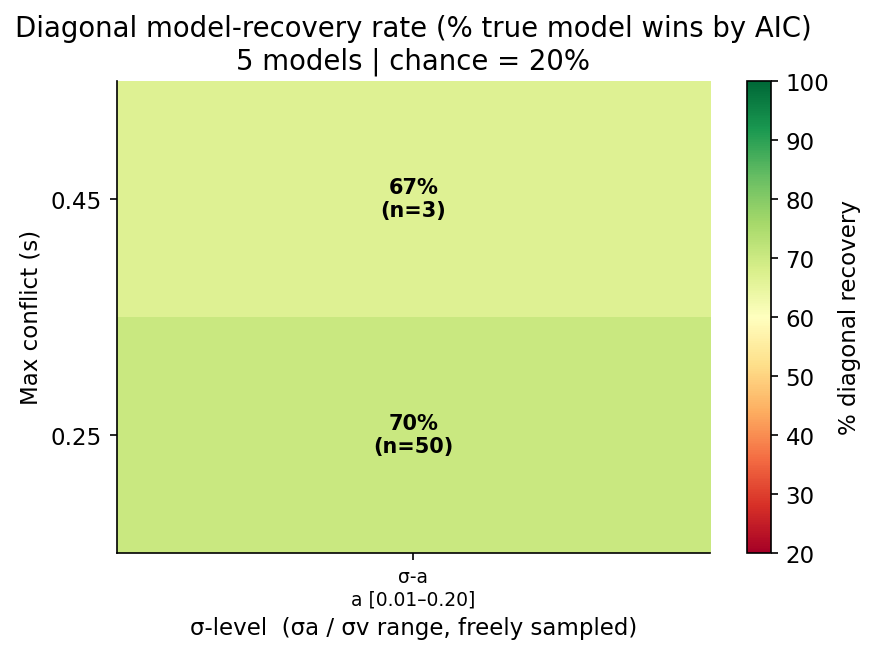

In [6]:
GRID_DIR = 'model_recovery_grid_results'

# Load all completed grid cell files (grid_sl*.json)
grid_cells = []
for fp in sorted(glob.glob(f'{GRID_DIR}/grid_sl*.json')):
    with open(fp) as f:
        d = json.load(f)
    models = d['models']
    per_model_diag = {
        m: (d['confusion_aic'][m][m] / max(sum(d['confusion_aic'][m].values()), 1))
        for m in models
    }
    grid_cells.append({
        'sigma_key':              d['sigma_key'],
        'sigma_label':            d['sigma_label'],
        'sigma_a_range':          tuple(d['sigma_a_range']),
        'sigma_v_range':          tuple(d['sigma_v_range']),
        'conflict_max':           d['conflict_max'],
        'n_iter':                 d['n_iter'],
        'nSimul':                 d['nSimul'],
        'mean_diag_recovery_aic': d['mean_diag_recovery_aic'],
        'per_model_diag_aic':     per_model_diag,
        'confusion_aic':          d['confusion_aic'],
        'models':                 models,
    })

grid = pd.DataFrame(grid_cells)
key_order    = ['a', 'b', 'c', 'd']
sigma_keys   = [k for k in key_order if k in grid['sigma_key'].values]
sigma_labels = [grid[grid['sigma_key'] == k]['sigma_label'].iloc[0] for k in sigma_keys]
cmaxes       = sorted(grid['conflict_max'].unique(), reverse=True)

print(f"Loaded {len(grid_cells)} grid cells  |  σ-levels: {sigma_keys}  |  cmaxes: {cmaxes}")
print(grid[['sigma_key', 'sigma_label', 'conflict_max', 'n_iter', 'nSimul', 'mean_diag_recovery_aic']].to_string(index=False))

# ── Heatmap: mean diagonal recovery ──────────────────────────────────────
Z = np.full((len(cmaxes), len(sigma_keys)), np.nan)
for i, cm in enumerate(cmaxes):
    for j, sk in enumerate(sigma_keys):
        row = grid[(grid['sigma_key'] == sk) & np.isclose(grid['conflict_max'], cm)]
        if len(row):
            Z[i, j] = row['mean_diag_recovery_aic'].iloc[0]

n_models = len(grid['models'].iloc[0]) if len(grid) else len(MODELS)
fig, ax = plt.subplots(figsize=(max(6, len(sigma_keys) * 2.5), 4.5))
im = ax.imshow(Z * 100, aspect='auto', cmap='RdYlGn', vmin=20, vmax=100)
ax.set_xticks(range(len(sigma_keys)))
ax.set_xticklabels(
    [f'σ-{k}\n{sigma_labels[j]}' for j, k in enumerate(sigma_keys)],
    fontsize=9)
ax.set_yticks(range(len(cmaxes)))
ax.set_yticklabels([f'{v:.2f}' for v in cmaxes])
ax.set_xlabel('σ-level  (σa / σv range, freely sampled)')
ax.set_ylabel('Max conflict (s)')
ax.set_title(f'Diagonal model-recovery rate (% true model wins by AIC)\n'
              f'{n_models} models | chance = {100/n_models:.0f}%')
for i in range(len(cmaxes)):
    for j in range(len(sigma_keys)):
        if not np.isnan(Z[i, j]):
            n = int(grid[(grid['sigma_key'] == sigma_keys[j]) &
                          np.isclose(grid['conflict_max'], cmaxes[i])]['n_iter'].iloc[0])
            ax.text(j, i, f'{Z[i, j]*100:.0f}%\n(n={n})',
                    ha='center', va='center', fontsize=10, fontweight='bold', color='black')
        else:
            ax.text(j, i, '—', ha='center', va='center', fontsize=12, color='gray')
fig.colorbar(im, ax=ax, label='% diagonal recovery')
plt.tight_layout()
os.makedirs('identifiability_figures', exist_ok=True)
plt.savefig('identifiability_figures/fig_diagonal_recovery_heatmap.pdf', bbox_inches='tight')
plt.savefig('identifiability_figures/fig_diagonal_recovery_heatmap.png', bbox_inches='tight', dpi=200)
plt.show()

## 6. Per-model diagonal recovery

/var/folders/_l/d96lf1k57sg3sgm171h4qx05_dn4td/T/ipykernel_93778/3886762368.py:36: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


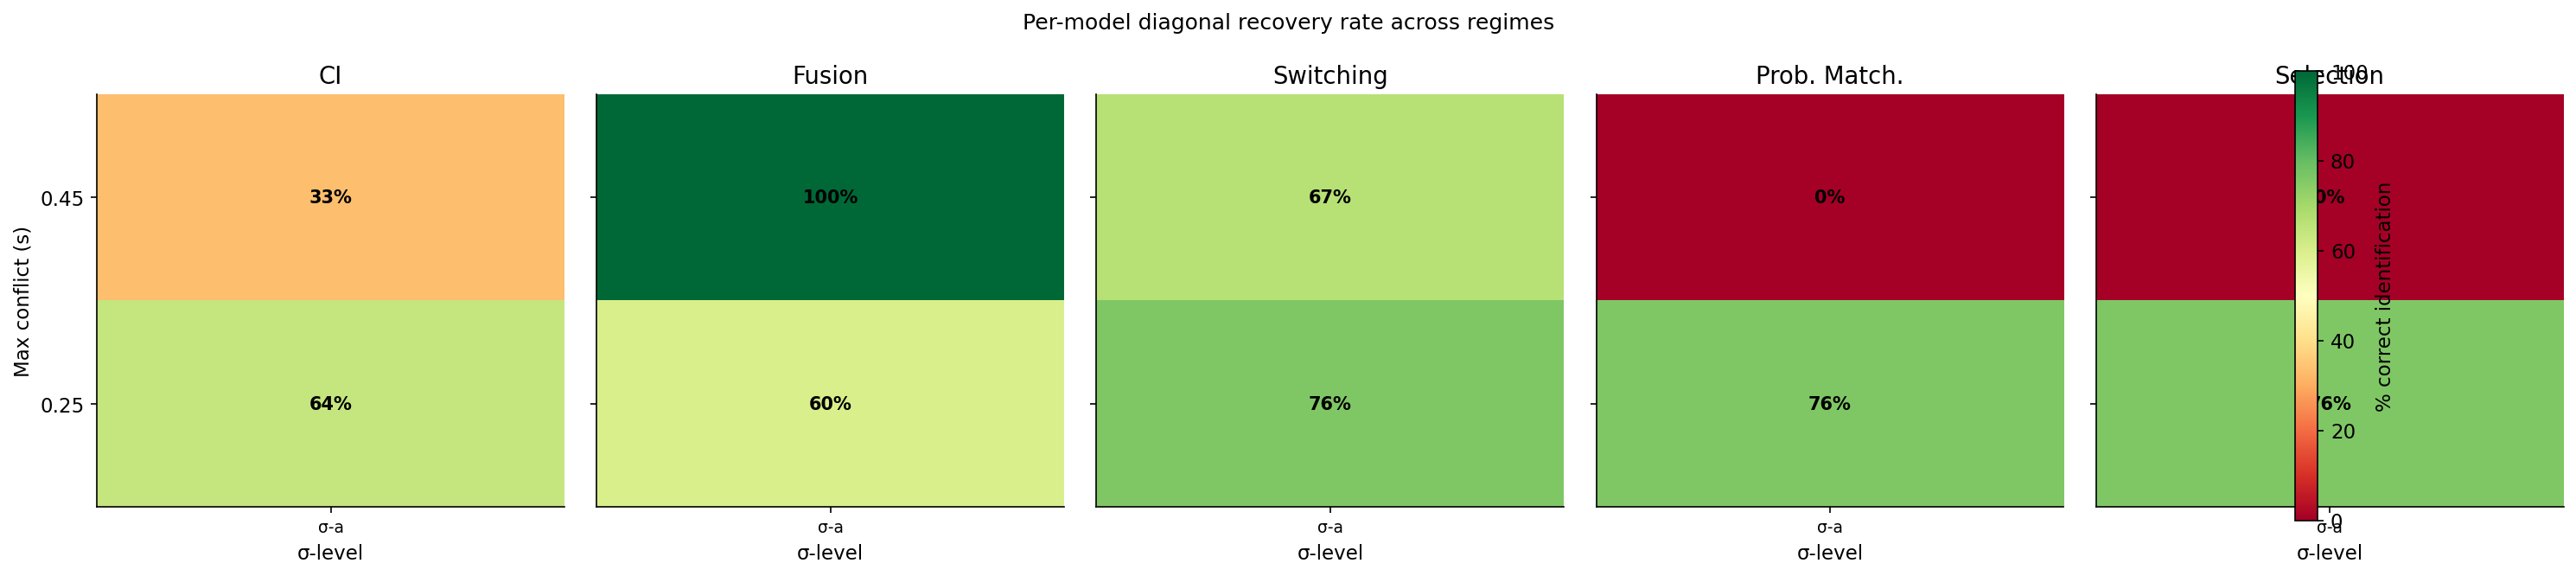

In [7]:
if not grid_cells:
    print('No grid cells loaded — run Section 5 first.')
else:
    model_list = list(grid['models'].iloc[0])

    fig, axes = plt.subplots(1, len(model_list),
                              figsize=(4 * len(model_list), 4.5), sharey=True)
    if len(model_list) == 1:
        axes = [axes]

    for ax, model in zip(axes, model_list):
        Zm = np.full((len(cmaxes), len(sigma_keys)), np.nan)
        for i, cm in enumerate(cmaxes):
            for j, sk in enumerate(sigma_keys):
                row = grid[(grid['sigma_key'] == sk) & np.isclose(grid['conflict_max'], cm)]
                if len(row):
                    Zm[i, j] = row['per_model_diag_aic'].iloc[0].get(model, 0)
        im = ax.imshow(Zm * 100, aspect='auto', cmap='RdYlGn', vmin=0, vmax=100)
        ax.set_xticks(range(len(sigma_keys)))
        ax.set_xticklabels([f'σ-{k}' for k in sigma_keys], fontsize=9)
        ax.set_yticks(range(len(cmaxes)))
        ax.set_yticklabels([f'{v:.2f}' for v in cmaxes])
        ax.set_xlabel('σ-level')
        if ax == axes[0]:
            ax.set_ylabel('Max conflict (s)')
        ax.set_title(MODEL_ABBR.get(model, model))
        for i in range(len(cmaxes)):
            for j in range(len(sigma_keys)):
                txt = f'{Zm[i, j]*100:.0f}%' if not np.isnan(Zm[i, j]) else '—'
                color = 'gray' if np.isnan(Zm[i, j]) else 'black'
                ax.text(j, i, txt, ha='center', va='center',
                        fontsize=10, fontweight='bold', color=color)

    fig.suptitle('Per-model diagonal recovery rate across regimes', fontsize=12)
    fig.colorbar(im, ax=axes, fraction=0.015, label='% correct identification')
    plt.tight_layout()
    plt.savefig('identifiability_figures/fig_per_model_recovery.pdf', bbox_inches='tight')
    plt.savefig('identifiability_figures/fig_per_model_recovery.png', bbox_inches='tight', dpi=200)
    plt.show()

## 7. Confusion matrices across regimes

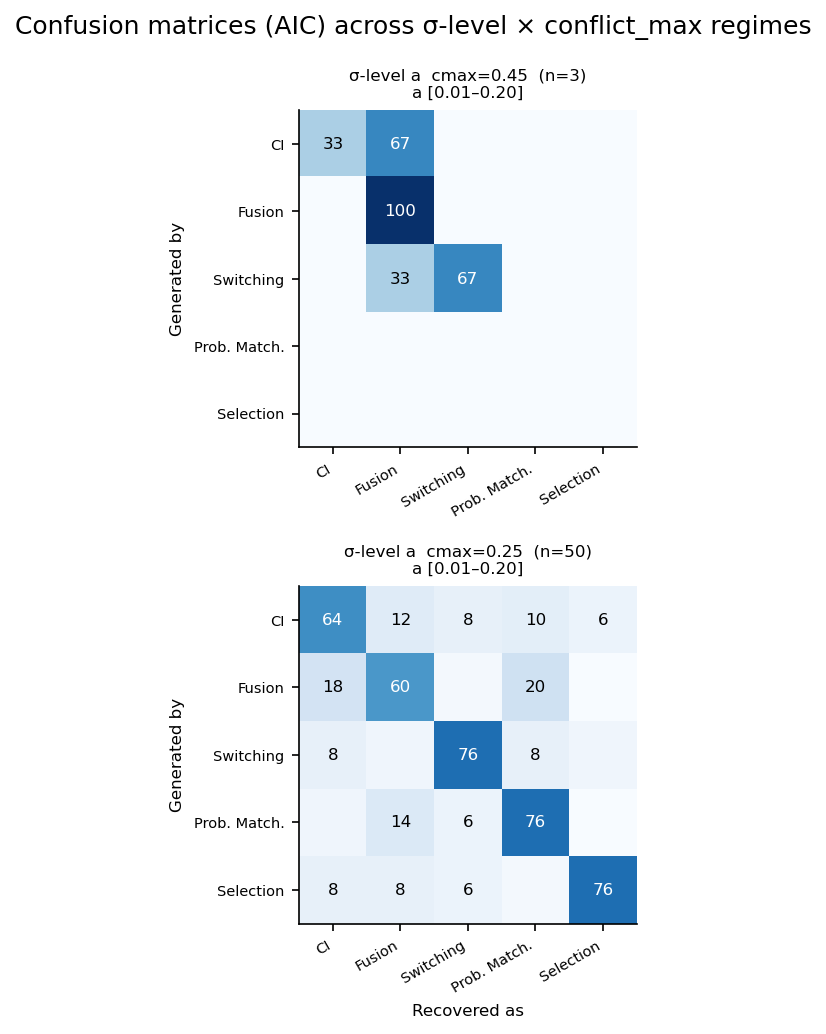

In [8]:
if not grid_cells:
    print('No grid cells loaded — run Section 5 first.')
else:
    sweep_models = list(grid['models'].iloc[0])
    abbrs = [MODEL_ABBR.get(m, m[:3]) for m in sweep_models]
    nm = len(sweep_models)

    nrows, ncols = len(cmaxes), len(sigma_keys)
    fig, axes = plt.subplots(nrows, ncols,
                              figsize=(3.5 * ncols, 3.5 * nrows), squeeze=False)

    for i, cm in enumerate(cmaxes):
        for j, sk in enumerate(sigma_keys):
            ax  = axes[i][j]
            row = grid[(grid['sigma_key'] == sk) & np.isclose(grid['conflict_max'], cm)]
            if not len(row):
                ax.set_visible(False)
                continue
            cell_row = row.iloc[0]
            mat = np.zeros((nm, nm))
            for ii, gen in enumerate(sweep_models):
                conf_row = cell_row['confusion_aic'].get(gen, {})
                tot = sum(conf_row.values()) or 1
                for jj, fit in enumerate(sweep_models):
                    mat[ii, jj] = conf_row.get(fit, 0) / tot
            im = ax.imshow(mat, vmin=0, vmax=1, cmap='Blues')
            ax.set_xticks(range(nm))
            ax.set_xticklabels(abbrs, fontsize=7, rotation=30, ha='right')
            ax.set_yticks(range(nm))
            ax.set_yticklabels(abbrs, fontsize=7)
            for ii in range(nm):
                for jj in range(nm):
                    if mat[ii, jj] > 0.05:
                        ax.text(jj, ii, f'{mat[ii, jj]*100:.0f}',
                                ha='center', va='center', fontsize=8,
                                color='white' if mat[ii, jj] > 0.5 else 'black')
            n = int(cell_row['n_iter'])
            ax.set_title(
                f'σ-level {sk}  cmax={cm:.2f}  (n={n})\n{cell_row["sigma_label"]}',
                fontsize=8)
            if j == 0:
                ax.set_ylabel('Generated by', fontsize=8)
            if i == nrows - 1:
                ax.set_xlabel('Recovered as', fontsize=8)

    fig.suptitle('Confusion matrices (AIC) across σ-level × conflict_max regimes',
                  fontsize=12)
    plt.tight_layout()
    plt.savefig('identifiability_figures/fig_confusion_matrices.pdf', bbox_inches='tight')
    plt.savefig('identifiability_figures/fig_confusion_matrices.png', bbox_inches='tight', dpi=200)
    plt.show()

## 8. PSE-curve separation by regime

Showing why the models are hard to distinguish: with empirical noise the predicted PSE curves are nearly identical, whereas lowering σ (and optionally extending conflict) separates them dramatically.

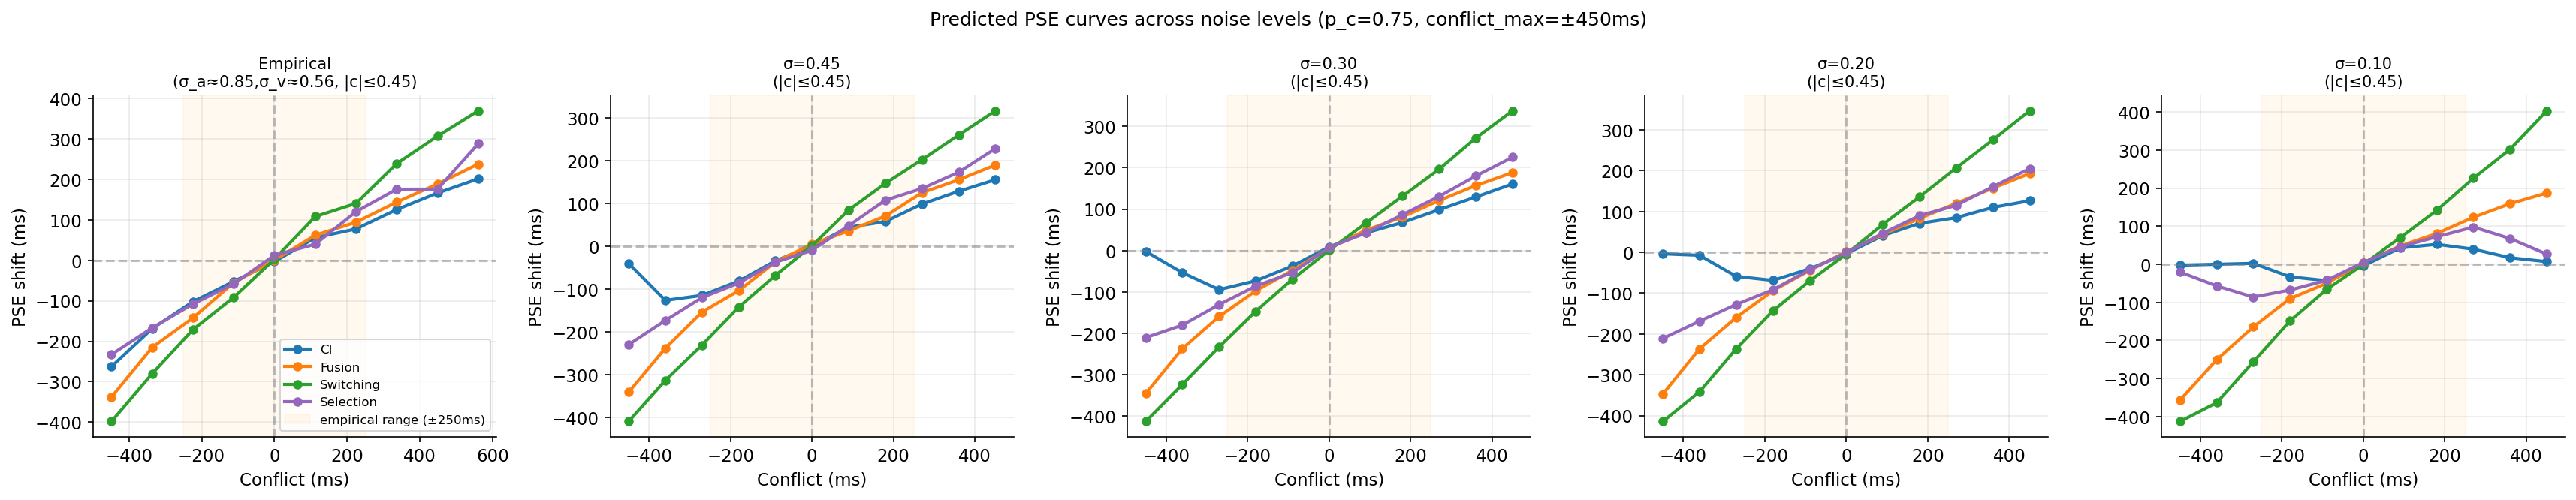

In [9]:
import sys
sys.path.insert(0, '.')
import compute_model_divergence as cmd

REGIMES = [
    ('Empirical\n(σ_a≈0.85,σ_v≈0.56, |c|≤0.45)',    0.85, 0.56),
    ('σ=0.45\n(|c|≤0.45)',               0.45, 0.45),
    ('σ=0.30\n(|c|≤0.45)',               0.30, 0.45),
    ('σ=0.20\n(|c|≤0.45)',               0.20, 0.45),
    ('σ=0.10\n(|c|≤0.45)',               0.10, 0.45),
]
M_COLORS = {'lognorm': 'C0', 'fusionOnlyLogNorm': 'C1', 'switchingFree': 'C2',
             'selection': 'C4'}
PLOT_MODELS = [m for m in cmd.DEFAULT_MODELS if m != 'probabilityMatchingLogNorm']

fig, axes = plt.subplots(1, 5, figsize=(23, 4.5), sharey=False)

for ax, (label, sigma, cmax) in zip(axes, REGIMES):
    template = cmd.build_template(conflict_max=cmax, n_conflict_steps=11,
                                   n_delta_steps=9, n_trials_per_cell=1000)
    for model in PLOT_MODELS:
        params = cmd.build_param_vector(model, sigma_a=sigma, sigma_v=sigma,
                                         p_c=0.75, lambda_=0.1)
        preds = cmd.predicted_p_longer(model, params, template)
        preds_snr = preds[np.isclose(preds['audNoise'], 1.2)]
        pse_per_conflict = []
        for c in sorted(preds_snr['conflictDur'].unique()):
            s = preds_snr[preds_snr['conflictDur']==c].sort_values('deltaDurS')
            ps = s['p_longer'].values
            ds = s['deltaDurS'].values * 1000
            pse = float(np.interp(0.5, ps, ds)) if ps.min()<=0.5<=ps.max() \
                  else ds[np.argmin(np.abs(ps-0.5))]
            pse_per_conflict.append((c*1000, pse))
        arr = np.array(pse_per_conflict)
        ax.plot(arr[:,0], arr[:,1], 'o-', color=M_COLORS[model],
                label=MODEL_ABBR[model], lw=2, ms=5)
    ax.axhline(0, color='gray', ls='--', alpha=0.5)
    ax.axvline(0, color='gray', ls='--', alpha=0.5)
    ax.set_xlabel('Conflict (ms)')
    ax.set_ylabel('PSE shift (ms)')
    ax.set_title(label, fontsize=10)
    ax.grid(alpha=0.25)
    ax.axvspan(-250, 250, color='orange', alpha=0.06, label='empirical range (±250ms)')

axes[0].legend(fontsize=8, loc='best')
fig.suptitle('Predicted PSE curves across noise levels (p_c=0.75, conflict_max=±450ms)',
              fontsize=12)
plt.tight_layout()
plt.savefig('identifiability_figures/fig_pse_curves_by_regime.pdf', bbox_inches='tight')
plt.savefig('identifiability_figures/fig_pse_curves_by_regime.png', bbox_inches='tight', dpi=200)
plt.show()

## 9. Summary: what experimental design would work?

Results below use ±80% Δ-duration range (matching real staircase) and conflict_max = 0.25 s, n = 15 iterations per generating model.

| Parameter | Empirical | Required for ≥70% recovery |
|-----------|-----------|-----------------------------|
| σ_a (log-space) | 0.28–0.82 (mean ≈ 0.55) | **≤ 0.30** |
| σ_v (log-space) | 0.14–1.84 (mean ≈ 0.57) | **≤ 0.30** |
| Max AV conflict | ±250 ms | ±250 ms is sufficient if σ is reduced |
| Diagonal recovery (3 models) | **~47%** (chance=33%) | **≥70%** |

**Key results (v2 sweep, ±80% delta):**

| σ | conflict_max | Mean diag | CI | Fusion | SwF |
|---|-------------|-----------|-----|--------|-----|
| 0.10 | 0.25 s | **89%** | 87% | 80% | 100% |
| 0.30 | 0.25 s | **69%** | 73% | 73% | 60% |
| 0.55 (empirical) | 0.25 s | **47%** | 40% | 60% | 40% |

**Practical implications:**
- Lower sensory noise requires higher-precision stimuli (e.g., ramp-duration discrimination with more training, 2-down-1-up staircase targeting 71% threshold)
- σ ≈ 0.30 is achievable with moderately practised observers and is sufficient for ~70% recovery
- σ ≈ 0.10 (Weber fraction ~10%) gives excellent recovery (89%) but requires highly practised observers
- Extending conflict range beyond ±250 ms gives only marginal improvement; reducing σ is the critical lever
- SwF is most often confused with Fusion at high noise (partial vs full integration are hard to distinguish)


In [10]:
print('=' * 80)
print('MODEL RECOVERY GRID — RESULTS SUMMARY')
print('=' * 80)
if not grid_cells:
    print('No results loaded — run Section 5 first.')
else:
    model_list   = list(grid['models'].iloc[0])
    abbr_headers = '  '.join(f'{MODEL_ABBR.get(m, m[:4]):>6}' for m in model_list)
    print(f"  {'lvl':>4}  {'cmax':>5}  {'n':>4}  {'nSimul':>6}  {'mean':>6}  {abbr_headers}  σa-range       σv-range")
    print('-' * 80)
    for _, row in grid.sort_values(['sigma_key', 'conflict_max']).iterrows():
        pm   = row['per_model_diag_aic']
        vals = '  '.join(f"{pm.get(m, 0)*100:>5.0f}%" for m in model_list)
        sar  = row['sigma_a_range']
        svr  = row['sigma_v_range']
        print(f"  {row['sigma_key']:>4}  {row['conflict_max']:5.2f}  {row['n_iter']:>4}  "
              f"{row['nSimul']:>6}  {row['mean_diag_recovery_aic']*100:5.1f}%  {vals}  "
              f"[{sar[0]:.2f}–{sar[1]:.2f}]  [{svr[0]:.2f}–{svr[1]:.2f}]")
    print('=' * 80)

MODEL RECOVERY GRID — RESULTS SUMMARY
   lvl   cmax     n  nSimul    mean      CI  Fusion  Switching  Prob. Match.  Selection  σa-range       σv-range
--------------------------------------------------------------------------------
     a   0.25    50     300   70.4%     64%     60%     76%     76%     76%  [0.01–0.20]  [0.01–0.20]
     a   0.45     3     100   66.7%     33%    100%     67%      0%      0%  [0.01–0.20]  [0.01–0.20]


Low noise  [σ ∈ 0.05–0.30]  →  mean diag = 88.0%  CI: 80%  Fusion: 93%  Switching: 91%
  [not yet available: results_high_noise/]


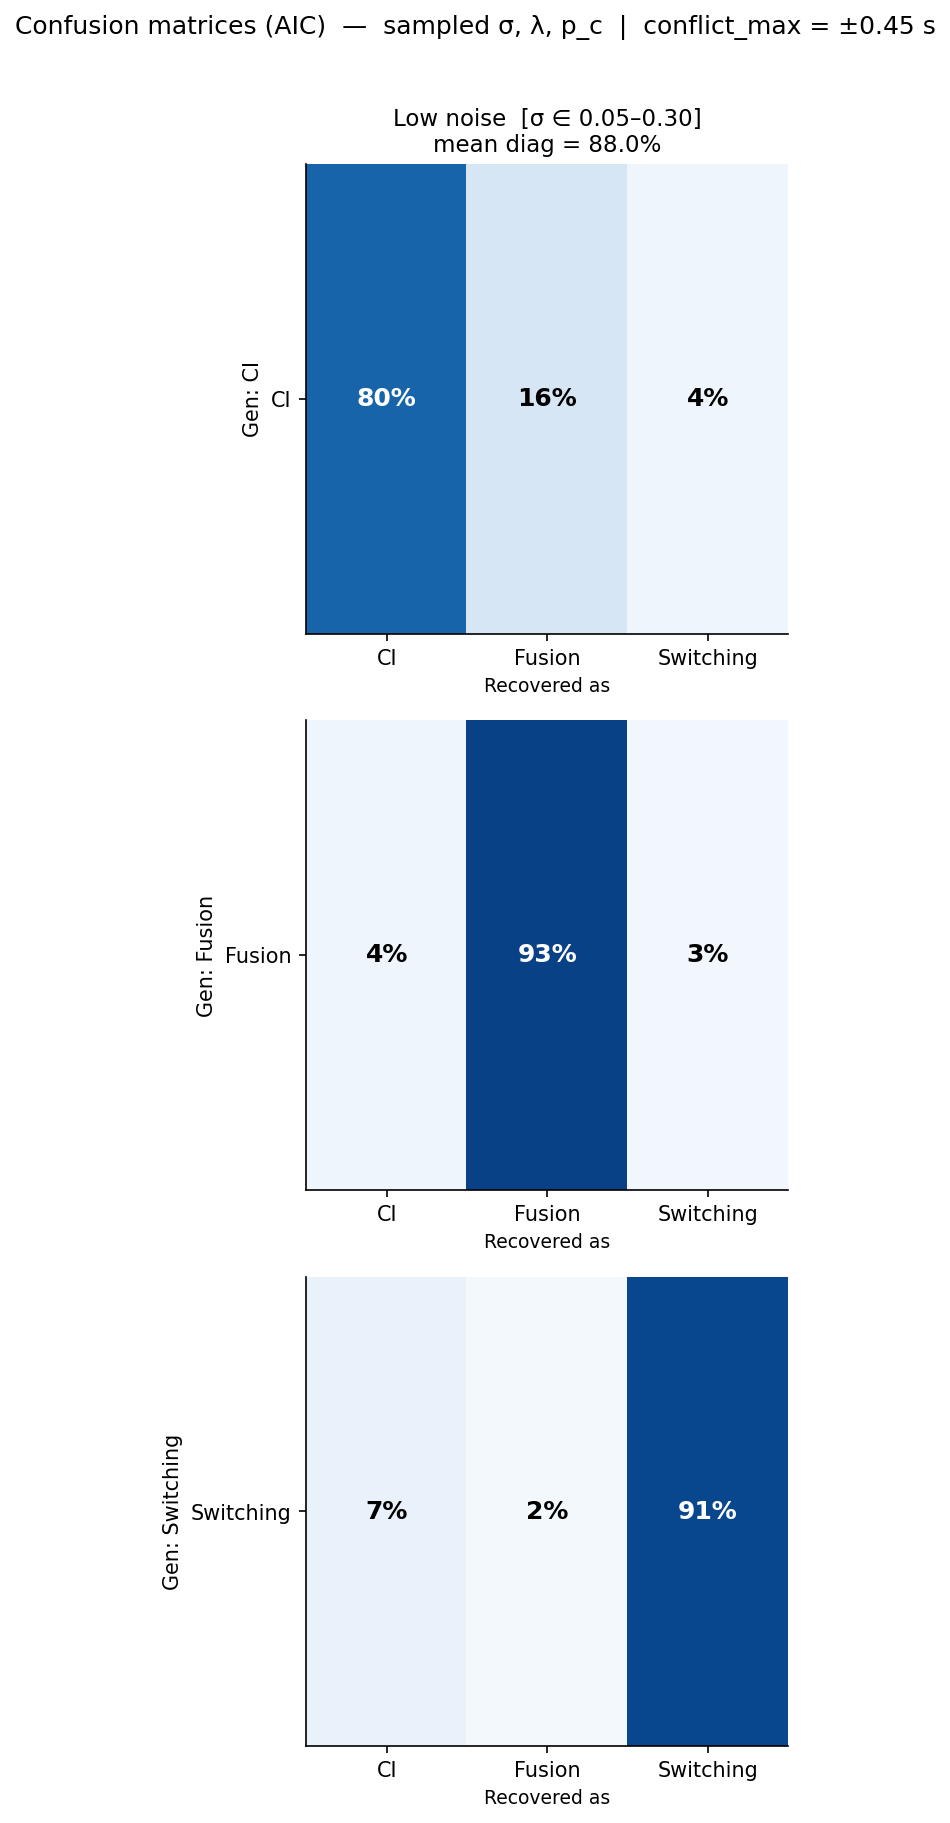

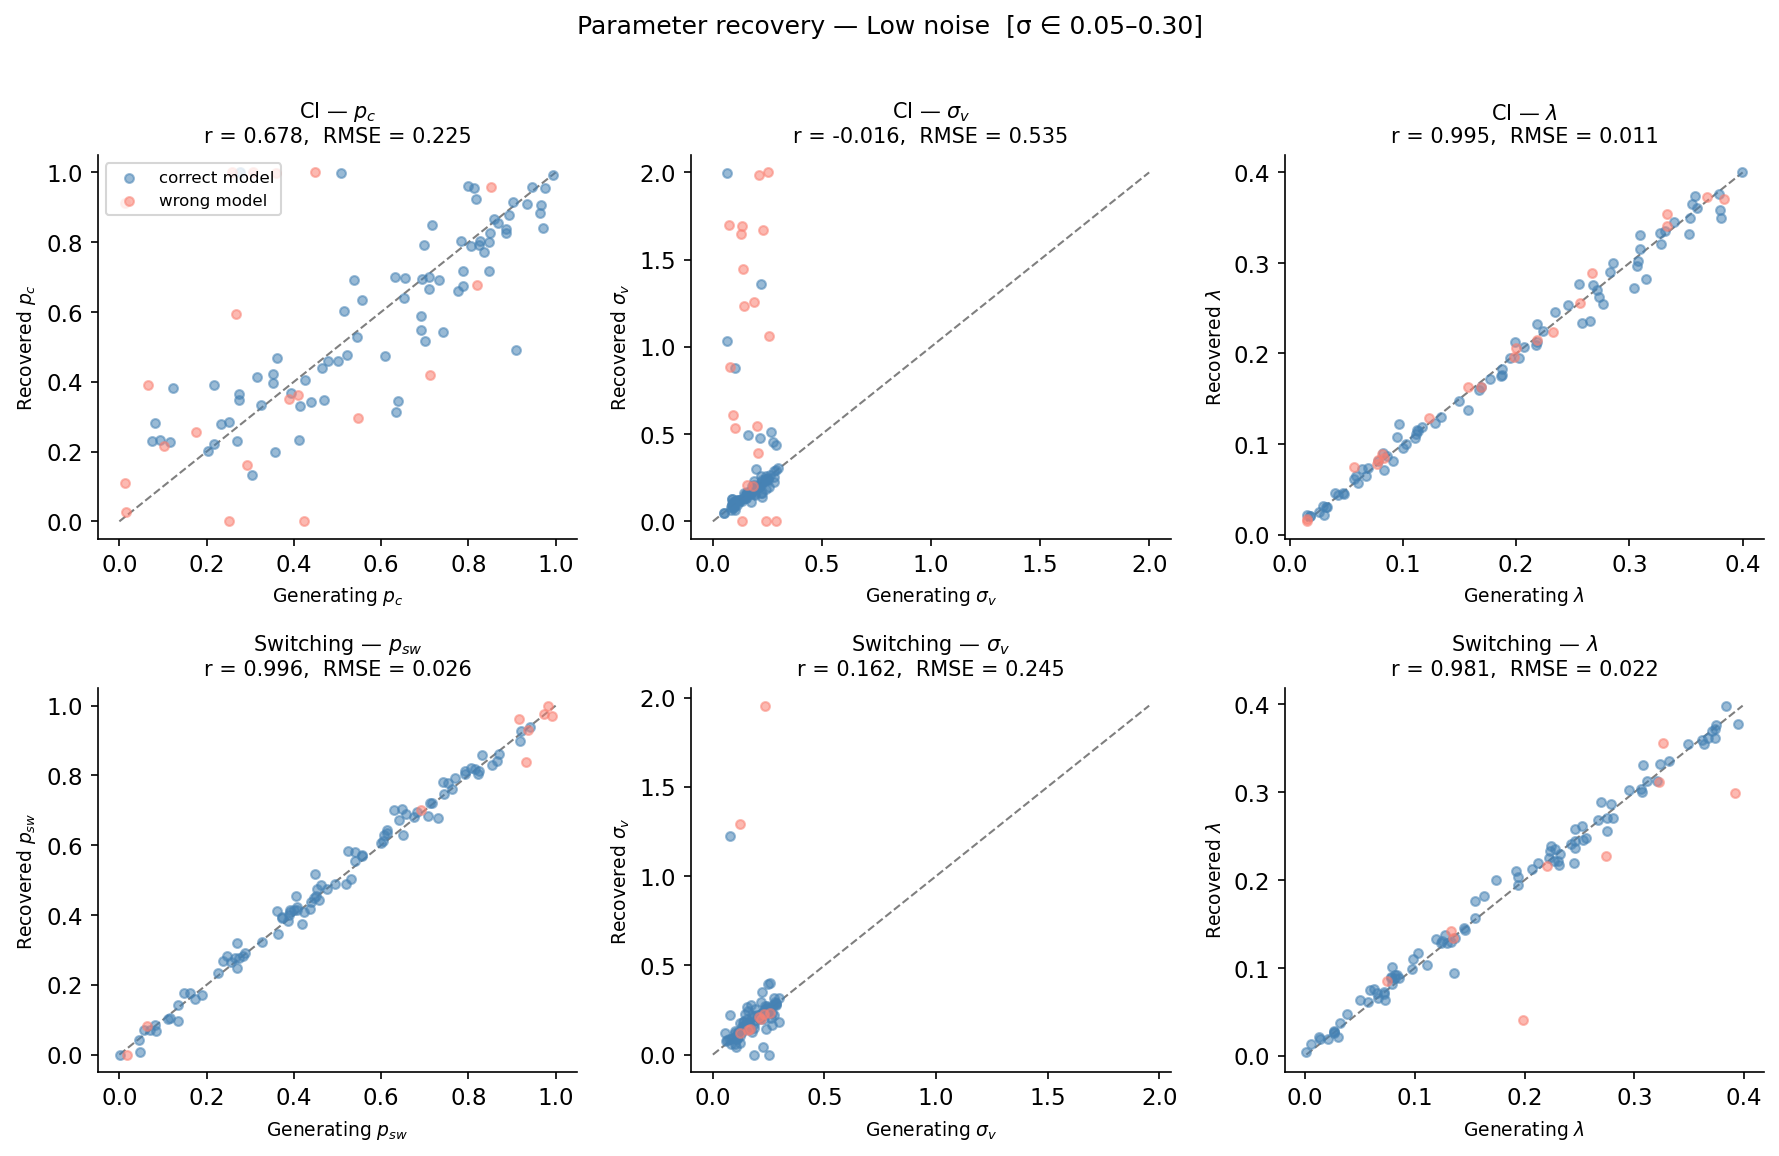

In [11]:
## 10. Sampled-parameter model recovery — low noise vs. high noise
#
# Two-case design: σ ∈ [0.05, 0.30] (low) vs σ ∈ [0.30, 0.70] (high/empirical).
# All parameters freely sampled: σa, σv, λ, p_c. conflict_max = ±0.45 s.
# Run run_model_recovery_sampled.py to generate results.

# ── Load results ──────────────────────────────────────────────────────────
CASES = {
    'Low noise  [σ ∈ 0.05–0.30]':  'results_low_noise',
    'High noise [σ ∈ 0.30–0.70]':  'results_high_noise',
}
SAMPLED_MODELS = ['lognorm', 'fusionOnlyLogNorm', 'switchingFree']

def load_sampled_case(d):
    rpath = os.path.join(d, 'recovery_results.json')
    cpath = os.path.join(d, 'recovery_params.csv')
    if not os.path.exists(rpath):
        return None, None
    with open(rpath) as f:
        res = json.load(f)
    df_p = pd.read_csv(cpath) if os.path.exists(cpath) else None
    return res, df_p

case_results, case_params = {}, {}
for label, d in CASES.items():
    r, p = load_sampled_case(d)
    if r is not None:
        case_results[label] = r
        case_params[label]  = p
        diag = r['mean_diag_recovery_aic']
        per  = r['per_model_diag_aic']
        print(f"{label}  →  mean diag = {diag*100:.1f}%  "
              + "  ".join(f"{MODEL_ABBR.get(m,m[:3])}: {per.get(m,0)*100:.0f}%"
                          for m in SAMPLED_MODELS))
    else:
        print(f"  [not yet available: {d}/]")

# ── Confusion matrices ────────────────────────────────────────────────────
if case_results:
    n_cases  = len(case_results)
    n_models = len(SAMPLED_MODELS)
    sm_abbrs = [MODEL_ABBR.get(m, m[:3]) for m in SAMPLED_MODELS]

    fig, axes = plt.subplots(n_models, n_cases,
                              figsize=(4.5 * n_cases, 4.0 * n_models), squeeze=False)

    for col, (label, results) in enumerate(case_results.items()):
        confusion = results['confusion_aic']
        diag      = results['mean_diag_recovery_aic']
        for row, gen_model in enumerate(SAMPLED_MODELS):
            ax  = axes[row][col]
            raw = confusion.get(gen_model, {})
            tot = sum(raw.values()) or 1
            mat = np.array([[raw.get(fm, 0) / tot for fm in SAMPLED_MODELS]])
            ax.imshow(mat, vmin=0, vmax=1, cmap='Blues', aspect='auto')
            ax.set_xticks(range(n_models)); ax.set_xticklabels(sm_abbrs, fontsize=10)
            ax.set_yticks([0])
            ax.set_yticklabels([MODEL_ABBR.get(gen_model, gen_model[:3])], fontsize=10)
            ax.set_xlabel('Recovered as', fontsize=9)
            for jj, fm in enumerate(SAMPLED_MODELS):
                v = raw.get(fm, 0) / tot
                ax.text(jj, 0, f'{v*100:.0f}%', ha='center', va='center',
                        fontsize=12, fontweight='bold',
                        color='white' if v > 0.6 else 'black')
            if row == 0:
                ax.set_title(f'{label}\nmean diag = {diag*100:.1f}%', fontsize=11)
            if col == 0:
                ax.set_ylabel(f'Gen: {MODEL_ABBR.get(gen_model, gen_model[:3])}', fontsize=10)

    fig.suptitle('Confusion matrices (AIC)  —  sampled σ, λ, p_c  |  conflict_max = ±0.45 s',
                  fontsize=12, y=1.01)
    plt.tight_layout()
    os.makedirs('identifiability_figures', exist_ok=True)
    plt.savefig('identifiability_figures/fig_sampled_confusion.pdf', bbox_inches='tight')
    plt.savefig('identifiability_figures/fig_sampled_confusion.png', bbox_inches='tight', dpi=200)
    plt.show()

# ── Parameter recovery scatterplots ──────────────────────────────────────
PLOT_PARAMS = {
    'lognorm':       ['p_c',   'sigma_v', 'lambda'],
    'switchingFree': ['p_sw',  'sigma_v', 'lambda'],
}
PARAM_LABEL = {
    'p_c': '$p_c$', 'p_sw': '$p_{sw}$',
    'sigma_v': r'$\sigma_v$', 'lambda': r'$\lambda$',
}

for label, df_params in case_params.items():
    if df_params is None:
        continue
    show_models = [m for m in SAMPLED_MODELS if m in PLOT_PARAMS]
    n_cols = max(len(v) for v in PLOT_PARAMS.values())
    n_rows = len(show_models)
    fig, axes = plt.subplots(n_rows, n_cols,
                              figsize=(4.0 * n_cols, 3.8 * n_rows), squeeze=False)
    for row, gen_model in enumerate(show_models):
        for col, param in enumerate(PLOT_PARAMS[gen_model]):
            ax   = axes[row][col]
            psub = df_params[(df_params['gen_model'] == gen_model) &
                              (df_params['param'] == param)].dropna(
                                  subset=['gen_value', 'rec_value'])
            if psub.empty:
                ax.set_visible(False); continue
            gv      = psub['gen_value'].values
            rv      = psub['rec_value'].values
            correct = psub['correct_aic'].values.astype(bool)
            ax.scatter(gv[correct],  rv[correct],  c='steelblue', s=18, alpha=0.55,
                       label='correct model', zorder=3)
            ax.scatter(gv[~correct], rv[~correct], c='salmon',    s=18, alpha=0.55,
                       label='wrong model',   zorder=3)
            lo, hi = min(gv.min(), rv.min()), max(gv.max(), rv.max())
            ax.plot([lo, hi], [lo, hi], 'k--', lw=1.0, alpha=0.5)
            r_val = float(np.corrcoef(gv, rv)[0, 1]) if len(gv) > 1 else float('nan')
            rmse  = float(np.sqrt(np.mean((gv - rv) ** 2)))
            plbl  = PARAM_LABEL.get(param, param)
            ax.set_title(f'{MODEL_ABBR.get(gen_model,"?")} — {plbl}\n'
                         f'r = {r_val:.3f},  RMSE = {rmse:.3f}', fontsize=10)
            ax.set_xlabel(f'Generating {plbl}', fontsize=9)
            ax.set_ylabel(f'Recovered {plbl}',  fontsize=9)
            if col == 0 and row == 0:
                ax.legend(fontsize=8, loc='upper left')
        for col in range(len(PLOT_PARAMS[gen_model]), n_cols):
            axes[row][col].set_visible(False)
    fig.suptitle(f'Parameter recovery — {label}', fontsize=12, y=1.01)
    plt.tight_layout()
    tag = label.split('[')[0].strip().replace(' ', '_')
    plt.savefig(f'identifiability_figures/fig_param_recovery_{tag}.pdf', bbox_inches='tight')
    plt.savefig(f'identifiability_figures/fig_param_recovery_{tag}.png', bbox_inches='tight', dpi=200)
    plt.show()